In [21]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [22]:
import os

import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

# module_path = os.path.abspath(os.path.join('..'))
# if module_path not in sys.path:
#     sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics         import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics         import roc_auc_score
from sklearn.metrics         import precision_recall_curve, classification_report
from sklearn.datasets         import make_classification

# Model import
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.ensemble       import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.linear_model   import LinearRegression
from sklearn.ensemble       import HistGradientBoostingClassifier
from sklearn.svm            import SVC
from sklearn.metrics        import classification_report
from xgboost                import XGBClassifier
from xgboost                import plot_importance
from lightgbm               import LGBMClassifier
from catboost               import CatBoostClassifier

# hyperopt 용
from hyperopt               import hp


# 사용자 Functions import
import HyperParams          as HP 
import utils.data_sampling  as ds 

from utils import user_utils    as uu
from utils import preprocessing as pp
from utils import data_sampling as ds
from utils import model_utils   as mu
from utils import modeling      as mo

In [23]:
# 결과받을 딕셔너리
results = {}

In [24]:
#1. 데이터 로딩
raw_df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [25]:
# 2. Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(raw_df, cols= 'Time')

In [26]:
# 3. 이상치를 경계값으로 치환
cap_X_feature = pp.cap_outliers(X_features)

In [27]:
# 4.1 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(cap_X_feature, y_target)

In [28]:
# 5.1 학습/검증 데이터 분리
X_tr, X_val, y_tr, y_val = pp.data_split(X_train, y_train, size=0.4)

In [ ]:
# 6. 하이퍼파라미터 튜닝
tuner = uu.HyperOptTuner(max_evals=100, random_state=23)

# HistGradientBoosting 탐색 공간 정의
hgb_search_space = {
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'max_iter': hp.choice('max_iter', [100, 150, 200, 250, 300, 400, 500]),   # 트리 개수
    'max_depth': hp.choice('max_depth', [None, 5, 10, 20]),
    'min_samples_leaf': hp.choice('min_samples_leaf', [10, 20, 30, 50]),
    'l2_regularization': hp.uniform('l2_regularization', 0.0, 1.0),
    'max_bins': hp.choice('max_bins', [128, 255])
}

# 모델 객체 생성
histgb = HistGradientBoostingClassifier(class_weight="balanced", random_state=23)

# 튜닝 실행
best_params, best_hgb, trials, exec_time = tuner.tune(
    histgb, X_tr, y_tr, X_val, y_val, hgb_search_space
)

# 결과 저장
model_name = 'hgb_ho_best'
results[model_name] = uu.get_model_train_eval(
    best_hgb, model_name, X_train, X_test, y_train, y_test, best_params
)


result_hgb = '''
최적 모델의 전체 평가 점수:
- roc_auc: 0.9842
- f1: 0.8231
- precision: 0.8897
- recall: 0.7658
- accuracy: 0.9994
✓ 모델 저장 완료: ../models\hgb_ho_best.pkl
  파일 크기: 0.27 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9764, '정확도': 0.9995, '정밀도': 0.8901, '재현율': 0.8265, 'F1': 0.8571 }
{'오차행렬':
[[56854    10]
 [   17    81]] }
실행 시간: 1.0117912292480469
하이퍼파라미터: {
    'l2_regularization': 0.7775071677100267, 
    'learning_rate': 0.07444330922448128, 
    'max_bins': 128, 
    'max_depth': 5, 
    'max_iter': 500, 
    'min_samples_leaf': 20
}
'''



HistGradientBoostingClassifier 튜닝 시작
100%|██████████| 100/100 [00:57<00:00,  1.72trial/s, best loss: -0.984226850524945]

튜닝 시간: 57.99초
최적 roc_auc: 0.9842

최적 모델의 전체 평가 점수:
- roc_auc: 0.9842
- f1: 0.8231
- precision: 0.8897
- recall: 0.7658
- accuracy: 0.9994
✓ 모델 저장 완료: ../models\hgb_ho_best.pkl
  파일 크기: 0.27 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9764, '정확도': 0.9995, '정밀도': 0.8901, '재현율': 0.8265, 'F1': 0.8571 }
{'오차행렬':
[[56854    10]
 [   17    81]] }
실행 시간: 1.0117912292480469
하이퍼파라미터: {'l2_regularization': 0.7775071677100267, 'learning_rate': 0.07444330922448128, 'max_bins': 128, 'max_depth': 5, 'max_iter': 500, 'min_samples_leaf': 20}


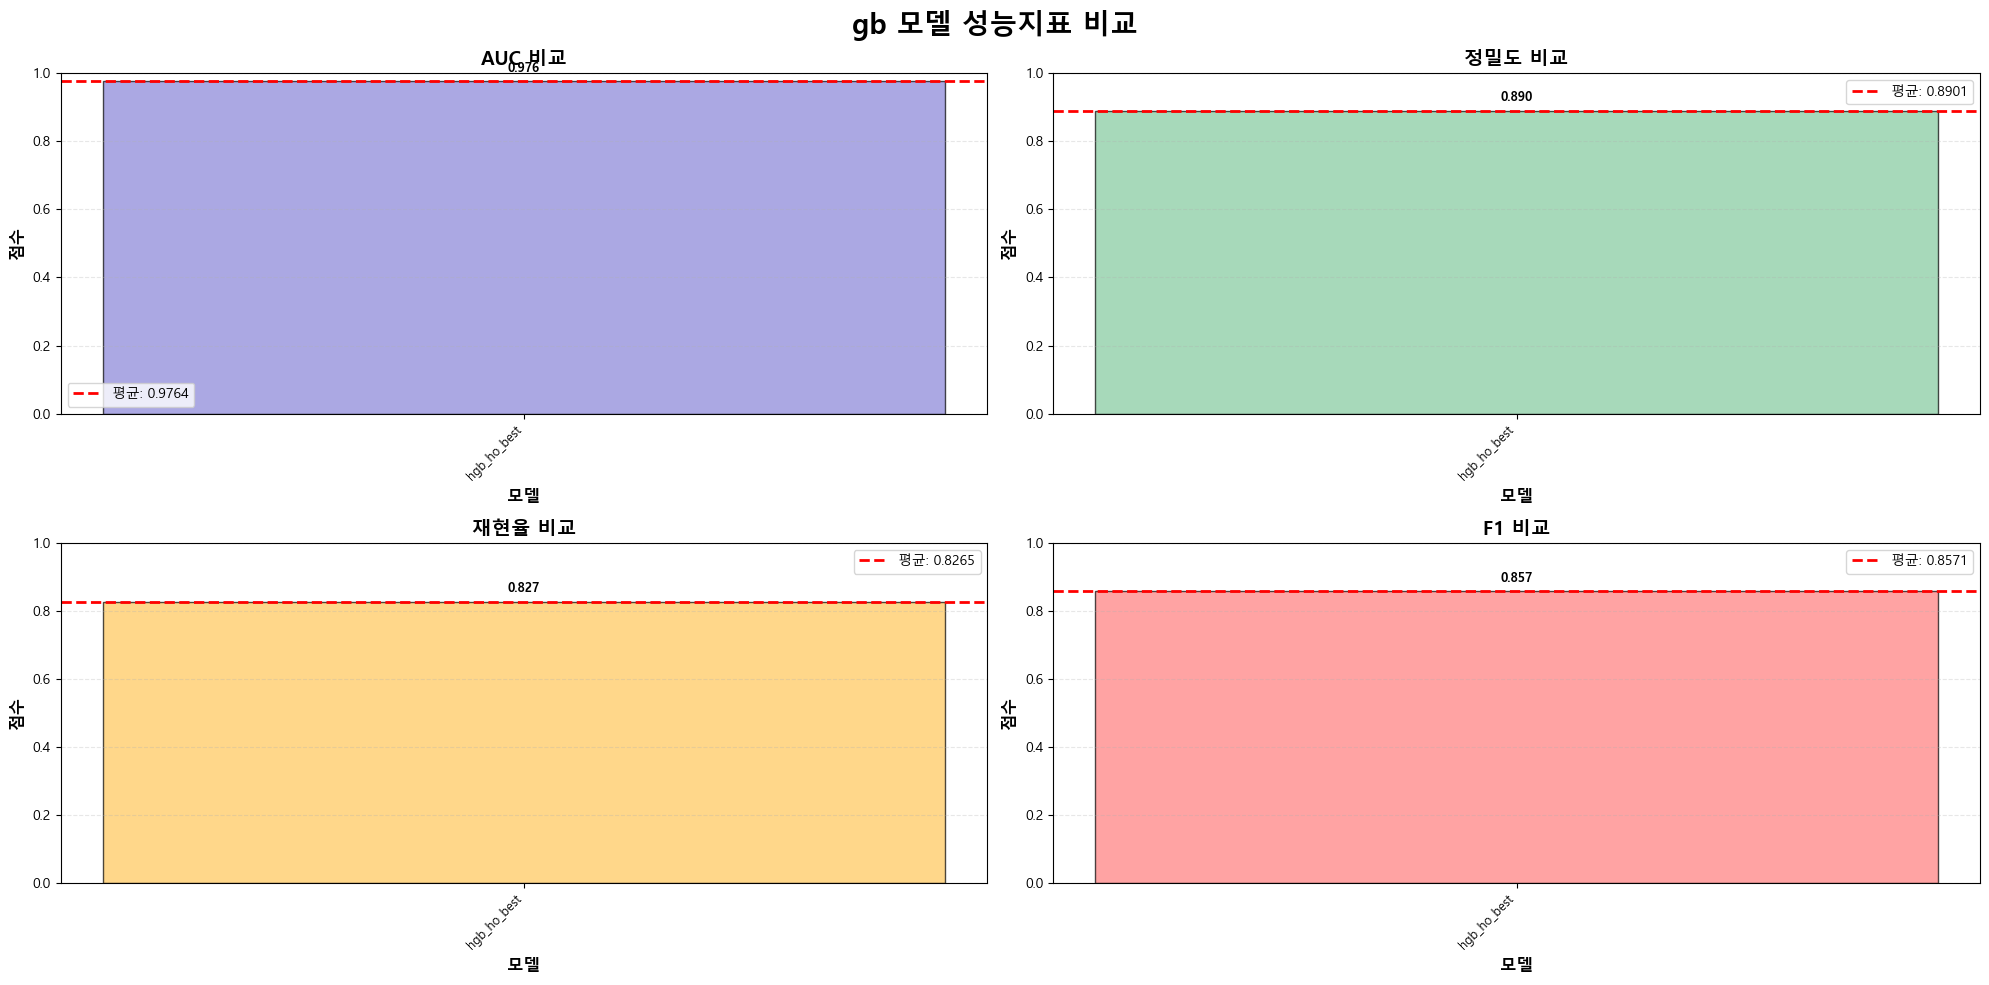


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9764 (hgb_ho_best)
  최저: 0.9764 (hgb_ho_best)
  평균: 0.9764
  표준편차: nan

[정밀도]
  최고: 0.8901 (hgb_ho_best)
  최저: 0.8901 (hgb_ho_best)
  평균: 0.8901
  표준편차: nan

[재현율]
  최고: 0.8265 (hgb_ho_best)
  최저: 0.8265 (hgb_ho_best)
  평균: 0.8265
  표준편차: nan

[F1]
  최고: 0.8571 (hgb_ho_best)
  최저: 0.8571 (hgb_ho_best)
  평균: 0.8571
  표준편차: nan


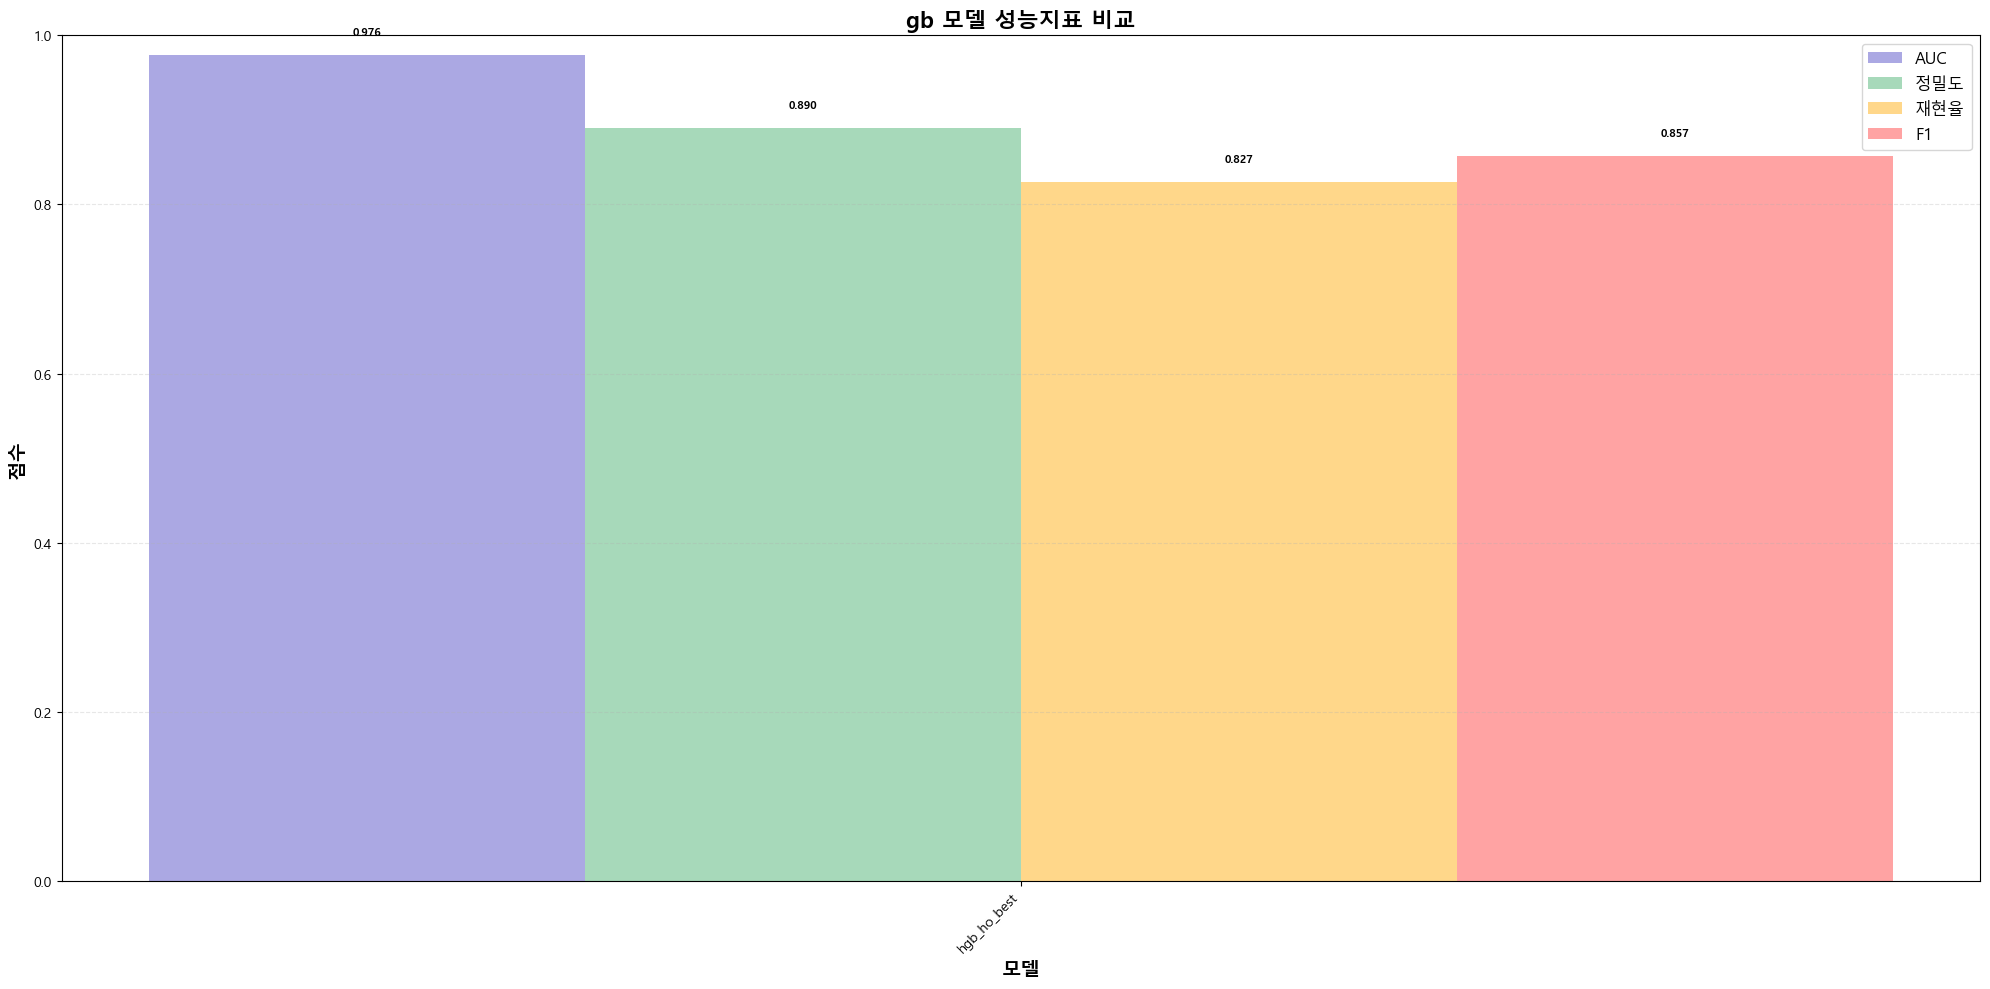


=== F1 Score 기준 상위 5개 모델 ===
                AUC     정밀도     재현율      F1
hgb_ho_best  0.9764  0.8901  0.8265  0.8571

=== AUC 기준 상위 5개 모델 ===
                AUC     정밀도     재현율      F1
hgb_ho_best  0.9764  0.8901  0.8265  0.8571

그래프가 저장되었습니다: ../images/gb_모델_성능지표_비교_2025_1130.png


In [30]:
# 7 시각화
mo.model_metrics_graph(results, 'gb 모델 성능지표 비교')